# Calibration Testing

Self-contained notebook in `calibration_testing/`:
1. Intrinsic calibration and intrinsic reprojection error
2. Undistort `source.jpg`
3. Plot pre-marked JSON points on undistorted image
4. Extrinsic solve in undistorted mode (`dist_coeffs = 0`) and reprojection error


In [24]:
import os
import json
from datetime import datetime

import cv2
import yaml
import pickle
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath('.')
if os.path.basename(ROOT) == 'calibration_testing':
    BASE_DIR = ROOT
else:
    BASE_DIR = os.path.join(ROOT, 'calibration_testing')

# ---------- Top-level config ----------
MODE = 'sink'  # change to 'sink' when needed
assert MODE in ('source', 'sink')

CB_DIR = os.path.join(BASE_DIR, 'checkerboard_2.8mm')
TARGET_DIR = os.path.join(BASE_DIR, MODE)

IMAGE_NAME = f'{MODE}.jpg'
SOURCE_IMAGE = os.path.join(TARGET_DIR, IMAGE_NAME)
COURT_INFO_INPUT = os.path.join(TARGET_DIR, 'court_info_input.json')

CAM_YAML = os.path.join(TARGET_DIR, 'camera_object.yaml')
CAM_PKL = os.path.join(TARGET_DIR, 'camera_object.pkl')
INTRINSIC_EVAL_JSON = os.path.join(TARGET_DIR, 'intrinsic_eval.json')
UNDISTORTED_IMAGE = os.path.join(TARGET_DIR, f'{MODE}_undistorted_new.png')
POINTS_PLOT_IMAGE = os.path.join(TARGET_DIR, f'{MODE}_points_on_undistorted.png')
EXTRINSIC_JSON = os.path.join(TARGET_DIR, 'extrinsic_pose_undistorted.json')
EXTRINSIC_OVERLAY = os.path.join(TARGET_DIR, f'{MODE}_extrinsic_reprojection_overlay.png')

os.makedirs(TARGET_DIR, exist_ok=True)
assert os.path.exists(CB_DIR), f'Missing checkerboard dir: {CB_DIR}'
assert os.path.exists(SOURCE_IMAGE), f'Missing source image: {SOURCE_IMAGE}'
assert os.path.exists(COURT_INFO_INPUT), f'Missing point json: {COURT_INFO_INPUT}'

print('BASE_DIR:', BASE_DIR)
print('MODE:', MODE)
print('TARGET_DIR:', TARGET_DIR)
print('SOURCE_IMAGE:', SOURCE_IMAGE)
print('COURT_INFO_INPUT:', COURT_INFO_INPUT)



BASE_DIR: /home/ubuntu/test_work/judex-web/calibration_testing
MODE: sink
TARGET_DIR: /home/ubuntu/test_work/judex-web/calibration_testing/sink
SOURCE_IMAGE: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink.jpg
COURT_INFO_INPUT: /home/ubuntu/test_work/judex-web/calibration_testing/sink/court_info_input.json


## Step 1: Intrinsic Calibration + Error


In [25]:
# Chessboard settings (same pattern used in your scripts)
CH_DIM = (6, 8)  # rows, cols in your current setup
SQ_SIZE_MM = 25.0
MIN_IMAGES = 3
IS_FISHEYE = False

obj_3d = np.zeros((CH_DIM[0] * CH_DIM[1], 3), np.float32)
idx = 0
for i in range(CH_DIM[0]):
    for j in range(CH_DIM[1]):
        obj_3d[idx][0] = i * SQ_SIZE_MM
        obj_3d[idx][1] = j * SQ_SIZE_MM
        idx += 1

ch_dim_cv = (CH_DIM[1], CH_DIM[0])
images = sorted([f for f in os.listdir(CB_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
assert images, 'No checkerboard images found.'

objpoints, imgpoints = [], []
ref_shape = None
corner_dir = os.path.join(TARGET_DIR, 'corner_images')
os.makedirs(corner_dir, exist_ok=True)

for name in images:
    p = os.path.join(CB_DIR, name)
    im = cv2.imread(p)
    if im is None:
        continue
    if ref_shape is None:
        ref_shape = im.shape[:2][::-1]  # width,height
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, ch_dim_cv, None)
    vis = im.copy()
    if ret:
        cv2.drawChessboardCorners(vis, ch_dim_cv, corners, ret)
        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (3, 3),
            (-1, -1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
        )
        objpoints.append(obj_3d)
        imgpoints.append(corners2)
    cv2.imwrite(os.path.join(corner_dir, name), vis)

assert len(objpoints) >= MIN_IMAGES, f'Need {MIN_IMAGES}+ detections, found {len(objpoints)}'

if IS_FISHEYE:
    K = np.zeros((3, 3))
    D = np.zeros((4, 1))
    objp = [np.asarray(pts, dtype=np.float32).reshape(-1, 1, 3) for pts in objpoints]
    imgp = [np.asarray(pts, dtype=np.float32).reshape(-1, 1, 2) for pts in imgpoints]
    flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_CHECK_COND + cv2.fisheye.CALIB_FIX_SKEW
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.fisheye.calibrate(
        objp, imgp, ref_shape, K, D, None, None, flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
    )
    calib_type = 'fisheye'
else:
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, ref_shape, None, None)
    calib_type = 'pinhole'

# Per-image reprojection error
per_image_errors = []
for i in range(len(objpoints)):
    proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], camera_matrix, dist_coeffs)
    err = np.sqrt(np.mean((imgpoints[i].reshape(-1, 2) - proj.reshape(-1, 2)) ** 2))
    per_image_errors.append(float(err))

intrinsic_eval = {
    'timestamp': datetime.now().isoformat(),
    'num_detected_images': len(objpoints),
    'opencv_rms': float(ret),
    'per_image_rmse': per_image_errors,
    'camera_matrix': camera_matrix.tolist(),
    'dist_coeffs': dist_coeffs.tolist(),
    'image_size': list(ref_shape),
    'calibration_type': calib_type,
}

with open(INTRINSIC_EVAL_JSON, 'w', encoding='utf-8') as f:
    json.dump(intrinsic_eval, f, indent=2)

cam_obj = {
    'camera_matrix': camera_matrix.tolist(),
    'dist_coeffs': dist_coeffs.tolist(),
    'image_size': list(ref_shape),
    'reprojection_error': float(ret),
    'calibration_type': calib_type,
    'rvecs': [r.tolist() for r in rvecs],
    'tvecs': [t.tolist() for t in tvecs],
    'date': datetime.now().isoformat(),
}
with open(CAM_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(cam_obj, f, sort_keys=False)
with open(CAM_PKL, 'wb') as f:
    pickle.dump(cam_obj, f)

print('Detected images:', len(objpoints))
print('OpenCV intrinsic RMS:', float(ret))
print('Per-image RMSE mean:', float(np.mean(per_image_errors)))
print('Saved:', CAM_YAML)
print('Saved:', INTRINSIC_EVAL_JSON)



Detected images: 63
OpenCV intrinsic RMS: 0.5699832007619512
Per-image RMSE mean: 0.3733674186089682
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/camera_object.yaml
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/intrinsic_eval.json


## Step 2: Undistort source image


Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_undistorted_new.png
Undistorted shape: (1080, 1440, 3)


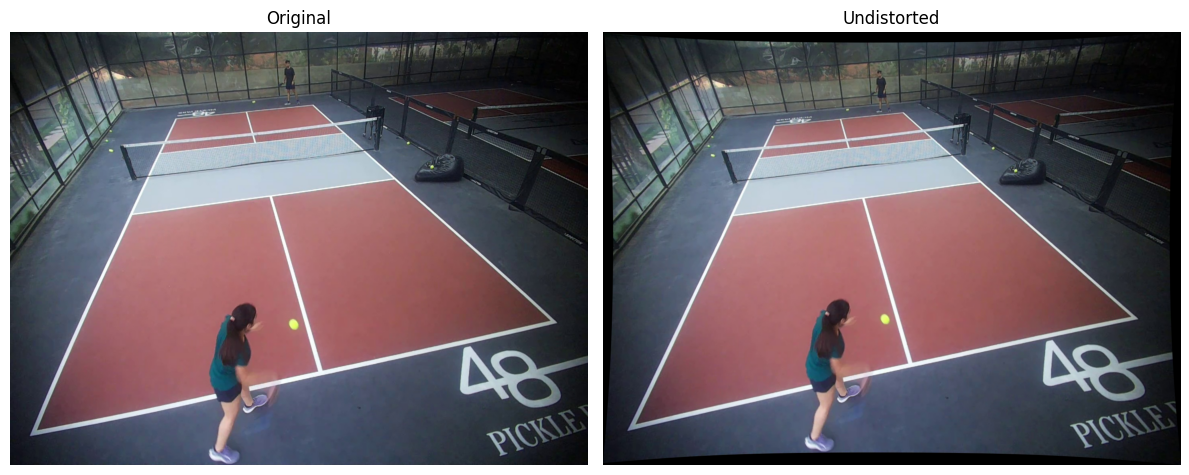

In [26]:
img = cv2.imread(SOURCE_IMAGE)
assert img is not None, f'Could not read {SOURCE_IMAGE}'
h, w = img.shape[:2]

if calib_type == 'fisheye':
    new_camera_matrix = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        camera_matrix, dist_coeffs, (w, h), np.eye(3), balance=1.0
    )
    undistorted = cv2.fisheye.undistortImage(
        img, camera_matrix, dist_coeffs, Knew=new_camera_matrix
    )
else:
    new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
        camera_matrix, dist_coeffs, (w, h), 1.0, (w, h)
    )
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs, None, new_camera_matrix)


cv2.imwrite(UNDISTORTED_IMAGE, undistorted)
print('Saved:', UNDISTORTED_IMAGE)
print('Undistorted shape:', undistorted.shape)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title('Original'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,2,2); plt.title('Undistorted'); plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.tight_layout()


## Step 3: Plot JSON-marked points on undistorted image


Loaded points: 6
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_points_on_undistorted.png


(np.float64(-0.5), np.float64(1439.5), np.float64(1079.5), np.float64(-0.5))

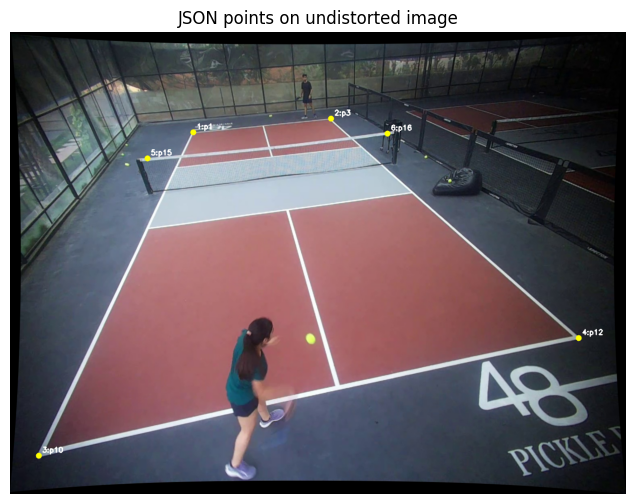

In [27]:
with open(COURT_INFO_INPUT, 'r', encoding='utf-8') as f:
    court_info = json.load(f)

world_points = np.asarray(court_info['world_points'], dtype=np.float32)
image_points = np.asarray(court_info['image_points'], dtype=np.float32)
point_names = court_info.get('point_names', [f'p{i+1}' for i in range(len(image_points))])

assert len(world_points) == len(image_points), 'world/image point count mismatch'

vis = undistorted.copy()
for i, (pt, name) in enumerate(zip(image_points, point_names), start=1):
    x, y = int(round(float(pt[0]))), int(round(float(pt[1])))
    cv2.circle(vis, (x, y), 7, (0, 255, 255), -1)
    cv2.putText(vis, f'{i}:{name}', (x+8, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

cv2.imwrite(POINTS_PLOT_IMAGE, vis)
print('Loaded points:', len(image_points))
print('Saved:', POINTS_PLOT_IMAGE)

plt.figure(figsize=(10,6))
plt.title('JSON points on undistorted image')
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')


## Step 4: Extrinsic solve + reprojection error (undistorted mode)


Extrinsic RMSE (px): 5.002546787261963
Extrinsic mean per-point error (px): 5.6187920570373535
Point 1: 0.7623 px
Point 2: 5.7830 px
Point 3: 1.1854 px
Point 4: 3.5571 px
Point 5: 11.8383 px
Point 6: 10.5867 px
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/extrinsic_pose_undistorted.json
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_extrinsic_reprojection_overlay.png


(np.float64(-0.5), np.float64(1439.5), np.float64(1079.5), np.float64(-0.5))

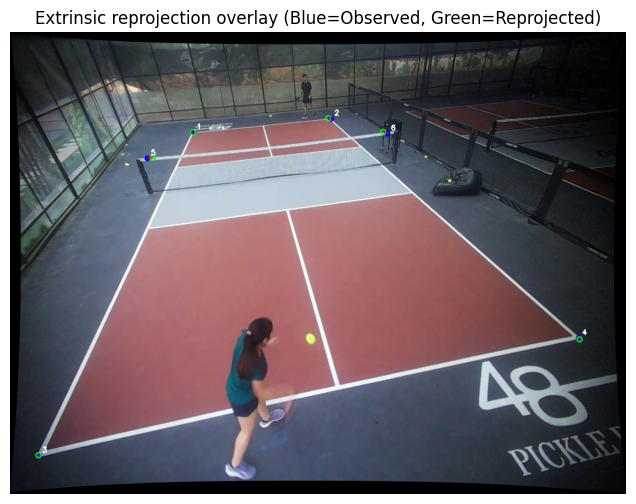

In [28]:
# Undistorted point mode: use zero distortion in solvePnP/projectPoints.
dist_zero = np.zeros((5, 1), dtype=np.float64)

ok, rvec, tvec = cv2.solvePnP(
    world_points,
    image_points,
    new_camera_matrix.astype(np.float64),
    dist_zero,
    useExtrinsicGuess=False,
    flags=cv2.SOLVEPNP_ITERATIVE,
)
assert ok, 'solvePnP failed'

rvec, tvec = cv2.solvePnPRefineVVS(
    world_points,
    image_points,
    new_camera_matrix.astype(np.float64),
    dist_zero,
    rvec,
    tvec,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 0.01),
)

reproj, _ = cv2.projectPoints(world_points, rvec, tvec, new_camera_matrix.astype(np.float64), dist_zero)
reproj = reproj.reshape(-1, 2)

diffs = image_points - reproj
per_point_err = np.linalg.norm(diffs, axis=1)
rmse = float(np.sqrt(np.mean((diffs) ** 2)))
mean_err = float(np.mean(per_point_err))

result = {
    'timestamp': datetime.now().isoformat(),
    'num_points': int(len(world_points)),
    'rmse_px': rmse,
    'mean_error_px': mean_err,
    'per_point_error_px': [float(x) for x in per_point_err],
    'rvec': rvec.flatten().tolist(),
    'tvec': tvec.flatten().tolist(),
    'camera_matrix_used': new_camera_matrix.tolist(),
    'dist_coeffs_used': dist_zero.flatten().tolist(),
}
with open(EXTRINSIC_JSON, 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2)

overlay = undistorted.copy()
for i, (obs, pred) in enumerate(zip(image_points, reproj), start=1):
    ox, oy = int(round(float(obs[0]))), int(round(float(obs[1])))
    px, py = int(round(float(pred[0]))), int(round(float(pred[1])))
    cv2.circle(overlay, (ox, oy), 7, (255, 0, 0), -1)      # observed
    cv2.circle(overlay, (px, py), 6, (0, 255, 0), 2)        # projected
    cv2.line(overlay, (ox, oy), (px, py), (0, 0, 255), 2)
    cv2.putText(overlay, f'{i}', (ox+8, oy-8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

cv2.imwrite(EXTRINSIC_OVERLAY, overlay)

print('Extrinsic RMSE (px):', rmse)
print('Extrinsic mean per-point error (px):', mean_err)
for i, e in enumerate(per_point_err, start=1):
    print(f'Point {i}: {float(e):.4f} px')
print('Saved:', EXTRINSIC_JSON)
print('Saved:', EXTRINSIC_OVERLAY)

plt.figure(figsize=(10,6))
plt.title('Extrinsic reprojection overlay (Blue=Observed, Green=Reprojected)')
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
